In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [2]:
words = open('names.txt' , 'r').read().splitlines()

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}  
stoi['.'] = 0                                
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
vocab_size

27

In [4]:
#build dataset
block_size = 3

def build_dataset(words):
    X ,Y = [] ,[]
    for w in words:
        context =[0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape , Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9 * len(words))

Xtr , Ytr = build_dataset(words[:n1])
Xdev , Ydev = build_dataset(words[n1:n2])
Xte , Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [5]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / ((n_embd * block_size)**0.5)
#b1 = torch.randn(n_hidden,                        generator=g)*0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g)*0.01
b2 = torch.randn(vocab_size,                      generator=g)*0

bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running =  torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1,n_hidden))
parameters = [C, W1, W2, b2 , bngain , bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

12097


In [6]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    
    hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
    #BatchNorm Layer
    #-----------------------------------------------------------
    bnmeani = hpreact.mean(0,keepdim = True)
    bnstdi = hpreact.std(0 , keepdim = True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

    with torch.no_grad():
        bnmean_running = 0.99* bnmean_running + 0.01 * bnmeani
        bnstd_running = 0.99 * bnstd_running + 0.01 * bnstdi
    #-----------------------------------------------------------
    #Non-Linearity
    #-----------------------------------------------------------
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3673
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9311
 140000/ 200000: 2.2231
 150000/ 200000: 2.0027
 160000/ 200000: 2.0997
 170000/ 200000: 2.4949
 180000/ 200000: 2.0199
 190000/ 200000: 2.1707


In [7]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1# + b1 # hidden layer pre-activation
    hpreact = bngain * (hpreact - hpreact.mean(0,keepdim = True)) /  hpreact.std(0 , keepdim = True) + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0677599906921387
val 2.1054909229278564


In [8]:
#-------------------------------- Pytorch-fying --------------------------------

In [15]:
class Linear :
    def __init__(self , fan_in , fan_out , bias = False):
        self.weight = torch.randn((fan_in , fan_out) , generator = g) / fan_in **0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self , x ):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias 
        return self.out
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    def __init__(self , dim , eps = 1e-5 , momentum = 0.1 ):
        self.eps = eps 
        self.momentum = momentum
        self.training = True
        #parameters (trained with bakcprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        #buffes ( trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self , x ):
        if self.training : 
            xmean = x.mean(0,keepdim = True)
            xvar = x.var(0 , keepdim = True)
        else :
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training : 
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    def parameters(self):
        return [self.gamma , self.beta]

class Tanh : 
    def __call__(self , x ):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

n_embd = 10 
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size , n_embd) , generator =g ) 

layers = [
    Linear(n_embd  * block_size , n_hidden) , BatchNorm1d(n_hidden) ,Tanh() ,
    Linear(          n_hidden , n_hidden) , BatchNorm1d(n_hidden) , Tanh(),
    Linear(          n_hidden , n_hidden) , BatchNorm1d(n_hidden) , Tanh(),
    Linear(          n_hidden , n_hidden) , BatchNorm1d(n_hidden) , Tanh(),
    Linear(          n_hidden , n_hidden) , BatchNorm1d(n_hidden) , Tanh(),
    Linear(          n_hidden , vocab_size) , BatchNorm1d(vocab_size),
]
with torch.no_grad():
    layers[-1].gamma *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer , Linear):
            layer.weight *= 1.0
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) 
for p in parameters :
    p.requires_grad = True

47024


In [16]:
max_steps = 200000
batch_size = 30
lossi = []
ud = []
best_loss = float('inf')
for i in range(max_steps):
    ix = torch.randint(0 , Xtr.shape[0] , (batch_size,) , generator = g )
    Xb , Yb = Xtr[ix] , Ytr[ix]
    #forward pass 
    emb = C[Xb]
    x = emb.view(emb.shape[0] , -1)
    for layer in layers : 
        x = layer(x)
    current_loss = F.cross_entropy(x , Yb)

    #backward pass 
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    current_loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if current_loss < best_loss:
        best_loss = current_loss
        # Save a copy of parameters (or use torch.save)
        best_params = [p.clone().detach() for p in parameters]
    if i % 10000 == 0 :
        print(f'{i:7d} / {max_steps:7d} : {loss.item() : .4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([
            (lr * p.grad.std() / p.data.std()).log10().item() 
            for p in parameters if p.grad is not None
        ])
    

      0 /  200000 :  2.5073
  10000 /  200000 :  2.5073
  20000 /  200000 :  2.5073
  30000 /  200000 :  2.5073
  40000 /  200000 :  2.5073
  50000 /  200000 :  2.5073
  60000 /  200000 :  2.5073
  70000 /  200000 :  2.5073
  80000 /  200000 :  2.5073
  90000 /  200000 :  2.5073
 100000 /  200000 :  2.5073
 110000 /  200000 :  2.5073
 120000 /  200000 :  2.5073
 130000 /  200000 :  2.5073
 140000 /  200000 :  2.5073
 150000 /  200000 :  2.5073
 160000 /  200000 :  2.5073
 170000 /  200000 :  2.5073
 180000 /  200000 :  2.5073
 190000 /  200000 :  2.5073


layer 2 (      Tanh): mean +0.00, std 0.70, saturated: 16.40%
layer 5 (      Tanh): mean -0.02, std 0.74, saturated: 18.07%
layer 8 (      Tanh): mean +0.00, std 0.75, saturated: 18.33%
layer 11 (      Tanh): mean +0.03, std 0.77, saturated: 18.37%
layer 14 (      Tanh): mean +0.03, std 0.78, saturated: 20.27%


C:\Users\abdou\AppData\Local\Temp\ipykernel_3332\4131817327.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))


Text(0.5, 1.0, 'activation distribution')

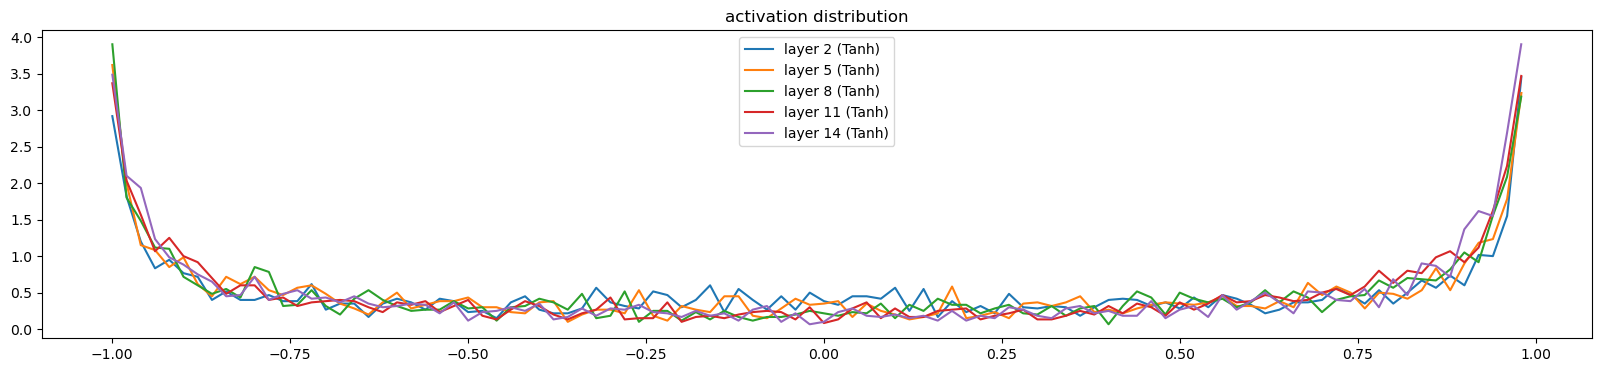

In [17]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean +4.97e-12, std 3.71e-03
layer 5 (      Tanh): mean -1.74e-11, std 3.53e-03
layer 8 (      Tanh): mean -1.12e-11, std 3.53e-03
layer 11 (      Tanh): mean -1.49e-11, std 3.54e-03
layer 14 (      Tanh): mean -1.55e-11, std 3.86e-03


Text(0.5, 1.0, 'gradient distribution')

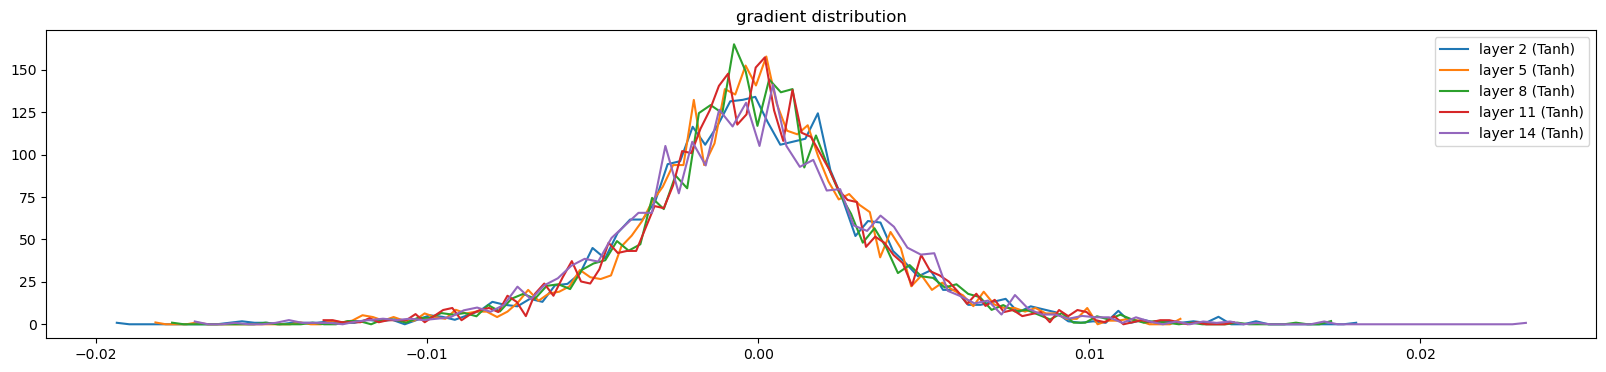

In [18]:
# visualize backward pass gradients distribution
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad  # inspect the GRADIENT of layer.out instead of values
        print('layer %d (%10s): mean %+.2e, std %.2e' % (
            i, 
            layer.__class__.__name__, 
            t.mean(), 
            t.std()
        ))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('gradient distribution')

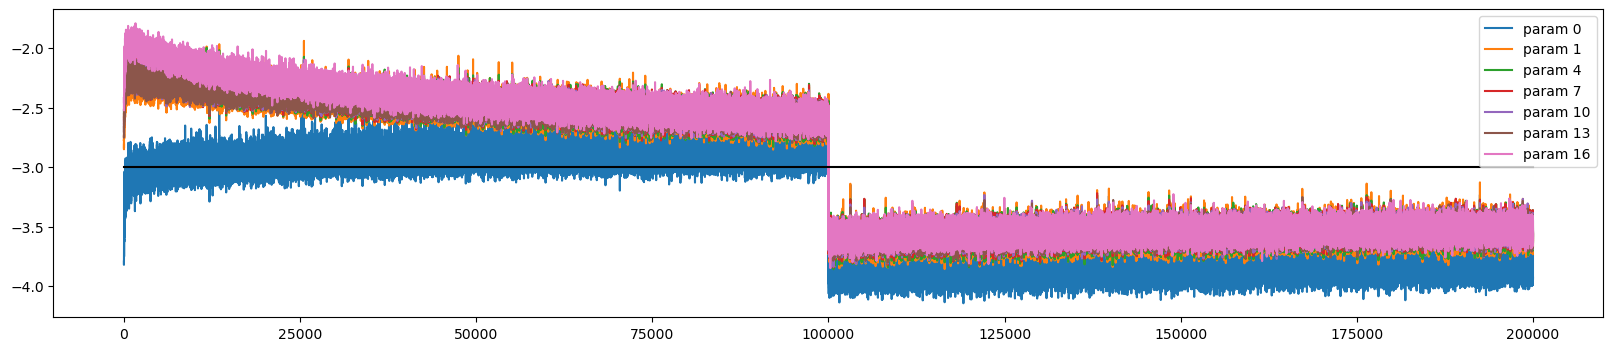

In [19]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);